<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:image.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---


## Tarea 04 – Aprendizaje automático

- **Fecha de Entrega:** 13 de noviembre de 2025, a las 23:59.
- **Fecha de publicación**: 30 de octubre de 2025.
- **Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 04 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

### 1.2 Pregunta de ciencia de datos

Esta tarea tendrá como objetivo crear un predictor que determine el éxito o fracaso de una expedición a distintas montañas del Himalayas según datos del montañista y de la expedición. Vamos a responder a la pregunta de qué tan bien pueden atributos como año, estación, montaña, edad del montañista, entre otros, predecir el éxito o fracaso de una expedición.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

[The Himalayan Database](https://www.himalayandatabase.com/) consiste en una colección de registros de expediciones en la cordillera del Himalaya. Esta contiene información detallada de las cimas más altas del mundo, junto con miles de expediciones realizadas desde 1905 hasta 2024 e información de cada uno de los/las montañistas que han participado en ellas. (El dataset que utilizaremos fue extraído desde: https://mavenanalytics.io/data-playground/himalayan-expeditions)

Descargue el archivo `Himalayan+Expeditions.zip` disponible en el repositorio del curso. Como puede ver, esta información está separada en varios archivos `.csv`. Deberá utilizar las herramientas aprendidas durante el curso para juntar esta información, procesarla y crear un predictor que determine el éxito de una subida.

**Recomendación**: Puede revisar el archivo `himalayan_data_dictionary.csv` para saber el significado de cada una de las columnas de la base de datos.

### 2.1 Librerías

Para esta tarea puede utilizar cualquiera de las librerías previamente utilizadas en el curso. Puede agregar otras si lo estima conveniente para el desarrollo de la Tarea.

In [1099]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# ...agreuge otras librerías si lo considera relevante

## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`memid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


In [1100]:
exped = pd.read_csv("exped.csv")

exped.columns

/tmp/ipykernel_1314/3619914720.py:1: DtypeWarning: Columns (8,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  exped = pd.read_csv("exped.csv")


Index(['expid', 'peakid', 'year', 'season', 'host', 'route1', 'route2',
       'route3', 'route4', 'nation', 'leaders', 'sponsor', 'success1',
       'success2', 'success3', 'success4', 'ascent1', 'ascent2', 'ascent3',
       'ascent4', 'claimed', 'disputed', 'countries', 'approach', 'bcdate',
       'smtdate', 'smttime', 'smtdays', 'totdays', 'termdate', 'termreason',
       'termnote', 'highpoint', 'traverse', 'ski', 'parapente', 'camps',
       'rope', 'totmembers', 'smtmembers', 'mdeaths', 'tothired', 'smthired',
       'hdeaths', 'nohired', 'o2used', 'o2none', 'o2climb', 'o2descent',
       'o2sleep', 'o2medical', 'o2taken', 'o2unkwn', 'othersmts', 'campsites',
       'accidents', 'achievment', 'agency', 'comrte', 'stdrte', 'primrte',
       'primmem', 'primref', 'primid', 'chksum'],
      dtype='object')

In [1101]:
himalayan = pd.read_csv("himalayan_data_dictionary.csv")

himalayan.columns

Index(['Table', 'Field', 'Description'], dtype='object')

In [1102]:
members = pd.read_csv("members.csv")

members.columns

#en el enunciado dice memid y no membid, como se parece se asume que es un error , lo mismo con myear

/tmp/ipykernel_1314/2744021632.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  members = pd.read_csv("members.csv")


Index(['expid', 'membid', 'peakid', 'myear', 'mseason', 'fname', 'lname',
       'sex', 'yob', 'citizen', 'status', 'residence', 'occupation', 'leader',
       'deputy', 'bconly', 'nottobc', 'support', 'disabled', 'hired', 'sherpa',
       'tibetan', 'msuccess', 'mclaimed', 'mdisputed', 'msolo', 'mtraverse',
       'mski', 'mparapente', 'mspeed', 'mhighpt', 'mperhighpt', 'msmtdate1',
       'msmtdate2', 'msmtdate3', 'msmttime1', 'msmttime2', 'msmttime3',
       'mroute1', 'mroute2', 'mroute3', 'mascent1', 'mascent2', 'mascent3',
       'mo2used', 'mo2none', 'mo2climb', 'mo2descent', 'mo2sleep',
       'mo2medical', 'mo2note', 'death', 'deathdate', 'deathtime', 'deathtype',
       'deathhgtm', 'deathclass', 'msmtbid', 'msmtterm', 'hcn', 'mchksum'],
      dtype='object')

In [1103]:
peaks_exp = pd.read_csv("peaks_with_exp.csv")

peaks_exp.columns

Index(['peakid', 'pkname', 'pkname2', 'location', 'heightm', 'heightf',
       'himal', 'region', 'open', 'unlisted', 'trekking', 'trekyear',
       'restrict', 'phost', 'pstatus', 'pyear', 'pseason', 'pmonth', 'pday',
       'pexpid', 'pcountry', 'psummiters', 'psmtnote', 'failed_exp',
       'success_exp'],
      dtype='object')

In [1104]:
peaks = pd.read_csv("peaks.csv")

peaks.columns

Index(['peakid', 'pkname', 'pkname2', 'location', 'heightm', 'heightf',
       'himal', 'region', 'open', 'unlisted', 'trekking', 'trekyear',
       'restrict', 'phost', 'pstatus', 'pyear', 'pseason', 'pmonth', 'pday',
       'pexpid', 'pcountry', 'psummiters', 'psmtnote'],
      dtype='object')

In [1105]:
exped_c = exped[["peakid","expid","year","season"]]
members_c = members[["peakid","expid","membid","myear","sex","yob","citizen","msuccess"]]
peaks_exp_c = peaks_exp[["peakid","pkname","heightm","success_exp","failed_exp"]]
peaks_c = peaks[["peakid","pkname","heightm"]]

In [1106]:
display(exped_c.head())
display(members_c.head())
display(peaks_exp_c.head())
display(peaks_c.head())

,peakid,expid,year,season
0,ANN2,ANN260101,1960,Spring
1,ANN2,ANN269301,1969,Autumn
2,ANN2,ANN273101,1973,Spring
3,ANN2,ANN278301,1978,Autumn
4,ANN2,ANN279301,1979,Autumn


,peakid,expid,membid,myear,sex,yob,citizen,msuccess
0,AMAD,AMAD01101,2,2001,M,1972.0,Australia,False
1,AMAD,AMAD01101,1,2001,M,1968.0,Australia,False
2,AMAD,AMAD01101,3,2001,M,1960.0,Australia,False
3,AMAD,AMAD01101,4,2001,M,1966.0,Australia,False
4,AMAD,AMAD01101,5,2001,F,1970.0,Australia,False


,peakid,pkname,heightm,success_exp,failed_exp
0,ACHN,Aichyn,6055,2,1
1,AMAD,Ama Dablam,6814,1123,453
2,AMOT,Amotsang,6393,1,2
3,AMPG,Amphu Gyabjen,5630,3,1
4,AMPH,Amphu I,6740,1,1


,peakid,pkname,heightm
0,ACHN,Aichyn,6055
1,AMAD,Ama Dablam,6814
2,AMOT,Amotsang,6393
3,AMPG,Amphu Gyabjen,5630
4,AMPH,Amphu I,6740


In [1107]:
df_1 = pd.merge(members_c , exped_c, on=["peakid","expid"])
df_2 = pd.merge(df_1 , peaks_exp_c, on=["peakid"])

df_2 = df_2.rename(columns={"membid" : "memid"}) 

df_unificado = df_2[[
    "peakid" , "pkname" , "heightm" , "expid" , "year" ,
    "season" , "memid" , "sex" , "yob" , "citizen" , "msuccess" ,
    "success_exp" , "failed_exp"
]]

In [1108]:
df_unificado.head()

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp
0,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,2,M,1972.0,Australia,False,1123,453
1,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,1,M,1968.0,Australia,False,1123,453
2,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,3,M,1960.0,Australia,False,1123,453
3,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,4,M,1966.0,Australia,False,1123,453
4,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,5,F,1970.0,Australia,False,1123,453


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

In [1109]:
#primero analizaremos los datos con info , dtype y describe 

display(df_unificado.info())
print("-"*40)
display(df_unificado.dtypes)
print("-"*40)
display(df_unificado.describe())
print("-"*40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   peakid       89089 non-null  object 
 1   pkname       89089 non-null  object 
 2   heightm      89089 non-null  int64  
 3   expid        89089 non-null  object 
 4   year         89089 non-null  int64  
 5   season       89089 non-null  object 
 6   memid        89089 non-null  int64  
 7   sex          89089 non-null  object 
 8   yob          83665 non-null  float64
 9   citizen      89082 non-null  object 
 10  msuccess     89089 non-null  bool   
 11  success_exp  89089 non-null  int64  
 12  failed_exp   89089 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 8.2+ MB


None

----------------------------------------


peakid          object
pkname          object
heightm          int64
expid           object
year             int64
season          object
memid            int64
sex             object
yob            float64
citizen         object
msuccess          bool
success_exp      int64
failed_exp       int64
dtype: object

----------------------------------------


,heightm,year,memid,yob,success_exp,failed_exp
count,89089.000000,89089.000000,89089.000000,83665.000000,89089.000000,89089.000000
mean,7921.765684,2003.426888,7.888381,1966.331154,728.087059,414.098643
std,845.990536,15.716337,8.401750,16.138675,602.811619,317.759808
min,5407.000000,1905.000000,1.000000,1849.000000,0.000000,0.000000
25%,7126.000000,1994.000000,3.000000,1956.000000,130.000000,146.000000
50%,8167.000000,2007.000000,5.000000,1967.000000,861.000000,453.000000
75%,8849.000000,2016.000000,10.000000,1978.000000,1495.000000,852.000000
max,8849.000000,2024.000000,99.000000,2024.000000,1495.000000,852.000000


----------------------------------------


In [1110]:
lista_indices = [
    "peakid" , "pkname" , "heightm" , "expid" , "year" ,
    "season" , "memid" , "sex" , "yob" , "citizen" , "msuccess" ,
    "success_exp" , "failed_exp"
] #si , solo copie lo anterior ;-;

for i in lista_indices:
    null = df_unificado[i].isnull().sum()
    print(f" {i} tiene {null} valores null")
    print("-"*30)

 peakid tiene 0 valores null
------------------------------
 pkname tiene 0 valores null
------------------------------
 heightm tiene 0 valores null
------------------------------
 expid tiene 0 valores null
------------------------------
 year tiene 0 valores null
------------------------------
 season tiene 0 valores null
------------------------------
 memid tiene 0 valores null
------------------------------
 sex tiene 0 valores null
------------------------------
 yob tiene 5424 valores null
------------------------------
 citizen tiene 7 valores null
------------------------------
 msuccess tiene 0 valores null
------------------------------
 success_exp tiene 0 valores null
------------------------------
 failed_exp tiene 0 valores null
------------------------------


podemos ver que yob tiene 5424 valores nulos , esto podria significar tanto duplica de valores como que , censillamente faltaran los datos , veremos esto mismo comparando con el total de datos que tiene yob y su porcentaje para poder tomar una decision

In [1111]:
cantidad = (len(df_unificado["yob"]))

print(f"yob tiene la cantidad de {cantidad} datos")
porc = (5424 / cantidad) * 100

print(f"yob tiene un porcentaje de {round(porc, 2)} datos null")


yob tiene la cantidad de 89089 datos
yob tiene un porcentaje de 6.09 datos null


In [1112]:
df_unificado[df_unificado["yob"].isnull()].head(10)  

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp
448,EVER,Everest,8849,EVER01131,2001,Spring,26,M,NaN,China,True,1495,852
804,TILI,Tilicho,7134,TILI01101,2001,Spring,7,M,NaN,Nepal,True,31,59
805,TILI,Tilicho,7134,TILI01101,2001,Spring,5,M,NaN,Nepal,True,31,59
806,TILI,Tilicho,7134,TILI01101,2001,Spring,6,M,NaN,Nepal,True,31,59
847,AMAD,Ama Dablam,6814,AMAD01304,2001,Autumn,7,M,NaN,Nepal,True,1123,453
848,AMAD,Ama Dablam,6814,AMAD01304,2001,Autumn,8,M,NaN,Nepal,True,1123,453
855,AMAD,Ama Dablam,6814,AMAD01305,2001,Autumn,7,M,NaN,Nepal,True,1123,453
857,AMAD,Ama Dablam,6814,AMAD01305,2001,Autumn,8,M,NaN,Nepal,True,1123,453
938,AMAD,Ama Dablam,6814,AMAD01317,2001,Autumn,5,M,NaN,Nepal,True,1123,453
939,AMAD,Ama Dablam,6814,AMAD01317,2001,Autumn,4,M,NaN,Nepal,True,1123,453


Podemos ver que , si bien faltan los valores null, el resto de datos estan , es decir, en las columnas se tiene el resto de datos, es por eso que no considero necesario el eliminar los datos, sin embargo, lo que se hara seria, tomando el valor de los datos que contienen tanto yob como citizen, se sustituiran los datos con la moda , ahora bien , podemos notar que hay 7 valores nulos en citizen. estos lo remplazaremos con el pais que mas presencia tiene en el dataframe

In [1113]:
ciudadanos = df_unificado["citizen"].mode()[0]
df_unificado.loc[:,"citizen"] = df_unificado["citizen"].fillna(ciudadanos)
print(df_unificado["citizen"].isnull().sum())
#pandas me tiro un "warmning" es por eso que tuve que modificar el codigo con el loc y asi 
#aqui esta la documentacion que lei [https://pandas.pydata.org/docs/user_guide/indexing.html]

0


In [1114]:

modas_pais = {}
paises = df_unificado["citizen"].unique()

for pais in paises:
    yob = df_unificado[df_unificado["citizen"] == pais]["yob"].dropna()
    
    if not yob.empty:
        moda = yob.mode()[0]
        modas_pais[pais] = moda
    else:
        print("algo fallo")

for pais , moda in modas_pais.items():
    remplazo = (df_unificado["citizen"] == pais) & (df_unificado["yob"].isnull())
    df_unificado.loc[remplazo, "yob"] = moda
restantes = df_unificado["yob"].isnull().sum()
if restantes > 0:
    print("el proceso fue exitoso , no quedan valores nulos en yob")
    print(f"el proceso fallo en {restantes} valores")
    print(f"se usara la moda general de yob en los {restantes} datos que sobran")
    moda_general = df_unificado["yob"].mode()[0]
    df_unificado.loc[df_unificado["yob"].isnull(), "yob"] = moda_general
    
    
restantes_v2 = df_unificado["yob"].isnull().sum()

print(f"quedaron {restantes_v2} valores nulos en yob")

algo fallo
algo fallo
algo fallo
algo fallo
el proceso fue exitoso , no quedan valores nulos en yob
el proceso fallo en 9 valores
se usara la moda general de yob en los 9 datos que sobran
quedaron 0 valores nulos en yob


In [1115]:
for i in lista_indices:   
    null = df_unificado[i].isnull().sum()
    print(f" {i} tiene {null} valores null")
    print("-"*30)

 peakid tiene 0 valores null
------------------------------
 pkname tiene 0 valores null
------------------------------
 heightm tiene 0 valores null
------------------------------
 expid tiene 0 valores null
------------------------------
 year tiene 0 valores null
------------------------------
 season tiene 0 valores null
------------------------------
 memid tiene 0 valores null
------------------------------
 sex tiene 0 valores null
------------------------------
 yob tiene 0 valores null
------------------------------
 citizen tiene 0 valores null
------------------------------
 msuccess tiene 0 valores null
------------------------------
 success_exp tiene 0 valores null
------------------------------
 failed_exp tiene 0 valores null
------------------------------


como podemos ver ya hemos solucionado el problema de que tengamos valores nulos, ahora, veremos los tipos / categorias de cada fila , para saber si podemos dejar/cambiar los tipos a otra

In [1116]:
display(df_unificado.info())
print("-"*40)
display(df_unificado.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   peakid       89089 non-null  object 
 1   pkname       89089 non-null  object 
 2   heightm      89089 non-null  int64  
 3   expid        89089 non-null  object 
 4   year         89089 non-null  int64  
 5   season       89089 non-null  object 
 6   memid        89089 non-null  int64  
 7   sex          89089 non-null  object 
 8   yob          89089 non-null  float64
 9   citizen      89089 non-null  object 
 10  msuccess     89089 non-null  bool   
 11  success_exp  89089 non-null  int64  
 12  failed_exp   89089 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 8.2+ MB


None

----------------------------------------


peakid          object
pkname          object
heightm          int64
expid           object
year             int64
season          object
memid            int64
sex             object
yob            float64
citizen         object
msuccess          bool
success_exp      int64
failed_exp       int64
dtype: object

In [1117]:
df_unificado.head()

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp
0,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,2,M,1972.0,Australia,False,1123,453
1,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,1,M,1968.0,Australia,False,1123,453
2,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,3,M,1960.0,Australia,False,1123,453
3,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,4,M,1966.0,Australia,False,1123,453
4,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,5,F,1970.0,Australia,False,1123,453


Podemos notar que yob es de un tipo float, sin embargo , aparenta ser que los datos que contiene son de tipo int , cosa que haria sentido, puesto que, si bien se puede nacer en "años decimales" , como por ejemplo 2006,5 siendo mitad de año del 2006 , lo mas correcto es escribirlo como int o directamente tipo date (se dejara como int por facilidad a futuro) , es por eso que veremos si los años contiene "datos flotantes" es decir, un dato pasadas las comillas

In [1118]:
resto = df_unificado["yob"] % 1

valores_flotantes = resto[resto != 0].sum()
print(f"la suma de los valores que posee yob en flotantes son {valores_flotantes}")

la suma de los valores que posee yob en flotantes son 0.0


In [1119]:
df_unificado.loc[:,"yob"] = df_unificado["yob"].astype(int)

In [1120]:
clean_df = df_unificado.copy()
clean_df.to_csv("clean_df.csv", index=False) #guardamos el dataframe limpio

In [1121]:
clean_df.head()

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp
0,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,2,M,1972.0,Australia,False,1123,453
1,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,1,M,1968.0,Australia,False,1123,453
2,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,3,M,1960.0,Australia,False,1123,453
3,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,4,M,1966.0,Australia,False,1123,453
4,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,5,F,1970.0,Australia,False,1123,453


### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

In [1122]:
clean_df["age"] = clean_df["year"] - clean_df["yob"]
clean_df.head()

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp,age
0,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,2,M,1972.0,Australia,False,1123,453,29.0
1,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,1,M,1968.0,Australia,False,1123,453,33.0
2,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,3,M,1960.0,Australia,False,1123,453,41.0
3,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,4,M,1966.0,Australia,False,1123,453,35.0
4,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,5,F,1970.0,Australia,False,1123,453,31.0


In [1123]:
clean_df["peak_success_p"]  = round(((clean_df["success_exp"] / (clean_df["success_exp"] + clean_df["failed_exp"])) * 100) , 3 )
clean_df.head()

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp,age,peak_success_p
0,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,2,M,1972.0,Australia,False,1123,453,29.0,71.256
1,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,1,M,1968.0,Australia,False,1123,453,33.0,71.256
2,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,3,M,1960.0,Australia,False,1123,453,41.0,71.256
3,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,4,M,1966.0,Australia,False,1123,453,35.0,71.256
4,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,5,F,1970.0,Australia,False,1123,453,31.0,71.256


In [1124]:
maximo = clean_df["peak_success_p"].max()
minimo = clean_df["peak_success_p"].min()

maximo_edad = clean_df["age"].max()
minimo_edad = clean_df["age"].min()

print(f"para peak_success el maximo es {maximo} y el minimo es {minimo}")
print("-"*40)
print(f"para age el maximo es {maximo_edad} y el minimo es {minimo_edad}")

para peak_success el maximo es 100.0 y el minimo es 0.0
----------------------------------------
para age el maximo es 156.0 y el minimo es -78.0


Podemos ver que , para peak_success los datos se ven correctos, no se tienen porcentajes negativos ni una taza mayor al 100% , ahora bien, para la columna age se pueden ver ,tanto edades negativas como edades que superan a la persona mas grande del mundo, es por eso que hay que encargarse de que estos datos sean congruentes

link de mi fuente con la persona mas anciana del mundo , aunque dudo que sea necesaria [https://www.guinnessworldrecords.com/world-records/oldest-person#:~:text=Su%20dieta%20tambi%C3%A9n%20era%20buena,de%20cuatro%20pistas%2C%20Time's%20Mistress.&text=Este%20navegador%20no%20puede%20reproducir%20este%20v%C3%ADdeo.)]

es por eso que tomaremos la mediana de los datos correctos , de forma que no vuelvan a pasar estos datos incorrectos para el calculo de la edad , asumiendo un minimo de 10 años y un maximo de 90 años

In [1125]:
edad_min = 10
edad_max = 90

edad_valida = clean_df[ (clean_df["age"] >= edad_min) & (clean_df["age"] <= edad_max) ]
promedio_valido = edad_valida["age"].median()
print(f"el promedio obtenido es {promedio_valido}")

el promedio obtenido es 36.0


In [1126]:
clean_df.loc[clean_df["age"] < edad_min , "age"] = promedio_valido
clean_df.loc[clean_df["age"] > edad_max , "age"] = promedio_valido

clean_df.head()

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp,age,peak_success_p
0,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,2,M,1972.0,Australia,False,1123,453,29.0,71.256
1,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,1,M,1968.0,Australia,False,1123,453,33.0,71.256
2,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,3,M,1960.0,Australia,False,1123,453,41.0,71.256
3,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,4,M,1966.0,Australia,False,1123,453,35.0,71.256
4,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,5,F,1970.0,Australia,False,1123,453,31.0,71.256


Ahora verificaremos que los datos esten de forma correcta

In [1127]:
maximo = clean_df["peak_success_p"].max()
minimo = clean_df["peak_success_p"].min()

maximo_edad = clean_df["age"].max()
minimo_edad = clean_df["age"].min()

print(f"para peak_success el maximo es {maximo} y el minimo es {minimo}")
print("-"*70)
print(f"para age el maximo es {maximo_edad} y el minimo es {minimo_edad}")

para peak_success el maximo es 100.0 y el minimo es 0.0
----------------------------------------------------------------------
para age el maximo es 86.0 y el minimo es 10.0


## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

## Respuesta a) 

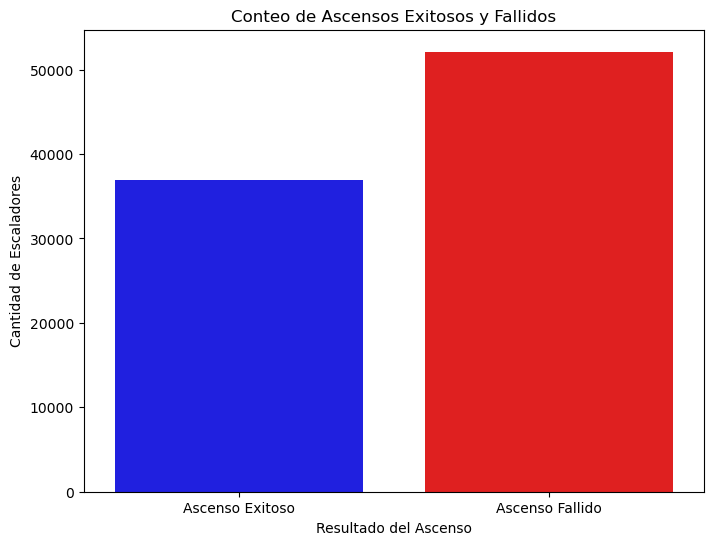

In [1128]:
conteos = clean_df["msuccess"].value_counts()
porcentaje = clean_df["msuccess"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,6))

datos = clean_df["msuccess"].map({
    True: "Ascenso Exitoso",
    False : "Ascenso Fallido"
})
sns.countplot(x = datos , palette=["red", "blue"] , hue = datos ,  order = ["Ascenso Exitoso" , "Ascenso Fallido"] , legend = False)
plt.title("Conteo de Ascensos Exitosos y Fallidos")  
plt.xlabel("Resultado del Ascenso")
plt.ylabel("Cantidad de Escaladores")
plt.show()


Con este grafico podemos ver que , lamentablemente hay mas ascensos fallidos que exitosos , sin embargo, nos interesa tambien ver su porcentaje con el total 

In [1129]:
exitos = conteos[True]
fallos = conteos[False]
total = exitos + fallos
porcentaje_exito = round((exitos / total) * 100 , 2)
porcentaje_fallo = round((fallos / total) * 100 , 2)

print(f"La cantidad de personas que tuvieron un ascenso exitoso es de {exitos}, esto representa un {porcentaje_exito}% del total de ascensos que se hicieron")
print("-" * 150)
print(f"La cantidad de personas que tuvieron un ascenso fallido es de {fallos}, esto representa un {porcentaje_fallo}% del total de ascensos que se hicieron")

La cantidad de personas que tuvieron un ascenso exitoso es de 36966, esto representa un 41.49% del total de ascensos que se hicieron
------------------------------------------------------------------------------------------------------------------------------------------------------
La cantidad de personas que tuvieron un ascenso fallido es de 52123, esto representa un 58.51% del total de ascensos que se hicieron


## Respuesta b)

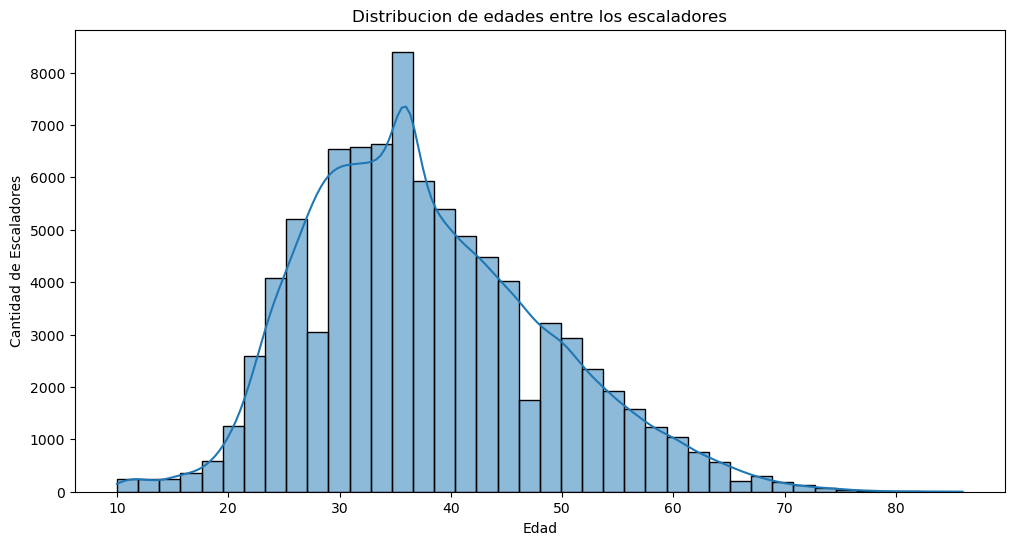

In [1130]:
plt.figure(figsize=(12,6))
# se leyo la documentacion como ayuda = [https://seaborn.pydata.org/generated/seaborn.histplot.html]  
sns.histplot(clean_df, x = "age" , bins = 40 , kde=True)
plt.title("Distribucion de edades entre los escaladores")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Escaladores")
plt.show()


Notar que hay edades donde aumenta el numero de escaladorores y otros donde decrece, curiosamente , sigue un patron similar (aunque no igual) a la campana de gauss , [a final de la tarea re hago el grafico con df_unificado, para ver como se ve el grafico sin el remplazo de datos extraños por su media]

## Respuesta c)

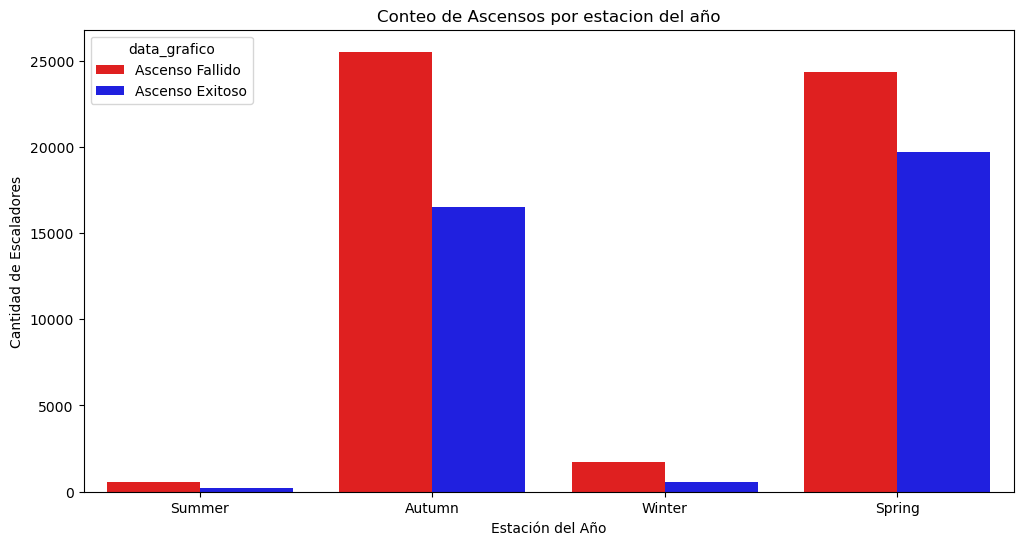

In [1131]:
copia = clean_df.copy()

copia["data_grafico"] = copia["msuccess"].map({
    True: "Ascenso Exitoso",
    False : "Ascenso Fallido"
})

plt.figure(figsize=(12,6))
sns.countplot(data = copia , hue = "data_grafico" , x = "season" , palette = ["red" , "blue"] , order = ["Summer" , "Autumn" , "Winter" , "Spring"] ) 
plt.title("Conteo de Ascensos por estacion del año")
plt.xlabel("Estación del Año")
plt.ylabel("Cantidad de Escaladores")
plt.show()

Aqui podemos ver como se distribuyen los ascensos en un grafico , cosa que nos permite rapidamente notar que , tanto en invierno como en verano , decrese mucho la cantidad de personas que desean subir a la cima de una montaña/monte/cordillera 

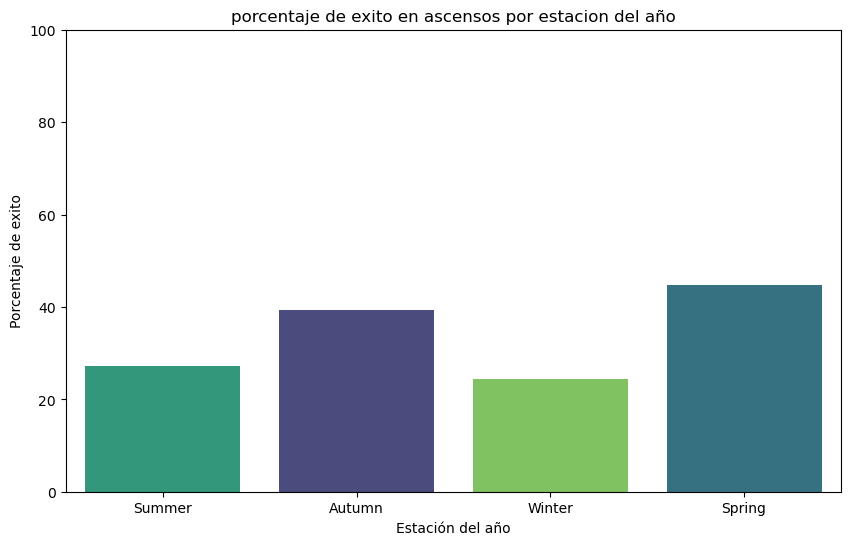

In [1132]:
exito_estacion = clean_df.groupby("season")["msuccess"].mean().reset_index()
exito_estacion["porcentaje"] = exito_estacion["msuccess"] * 100

plt.figure(figsize=(10,6))

sns.barplot(data = exito_estacion , x = "season" , hue = "season", y = "porcentaje" , palette="viridis" , order = ["Summer" , "Autumn" , "Winter" , "Spring"] , legend=False)

plt.title("porcentaje de exito en ascensos por estacion del año")
plt.xlabel("Estación del año")
plt.ylabel("Porcentaje de exito")
plt.ylim(0, 100)
plt.show()


Con esto podemos ver de forma grafica los porcentajes de exito en cada estacion, por ultimo , tendremos los porcentajes mostrados de forma impresa

In [1133]:
estacion = ["Autumn" , "Spring" , "Summer" , "Winter"]
data = clean_df.groupby("season")["msuccess"].mean() * 100

for i in estacion:
    exito = round(data[i] , 3)
    fracaso = round(100 - exito , 3)
    print(f"En la estacion de {i} el porcentaje de exito es de {exito}% , mientras que el porcentaje de fracaso es de {fracaso}%")
    print("-"*120)

En la estacion de Autumn el porcentaje de exito es de 39.266% , mientras que el porcentaje de fracaso es de 60.734%
------------------------------------------------------------------------------------------------------------------------
En la estacion de Spring el porcentaje de exito es de 44.742% , mientras que el porcentaje de fracaso es de 55.258%
------------------------------------------------------------------------------------------------------------------------
En la estacion de Summer el porcentaje de exito es de 27.154% , mientras que el porcentaje de fracaso es de 72.846%
------------------------------------------------------------------------------------------------------------------------
En la estacion de Winter el porcentaje de exito es de 24.414% , mientras que el porcentaje de fracaso es de 75.586%
------------------------------------------------------------------------------------------------------------------------


## Respuesta d)

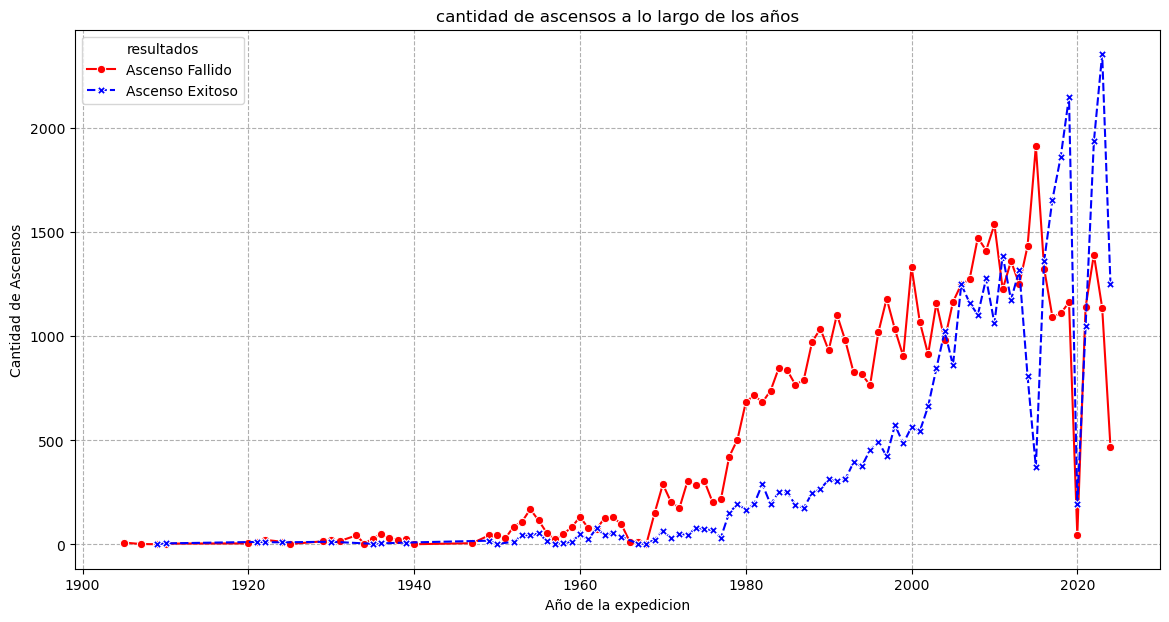

In [1134]:
ascensos = clean_df.groupby(["year" , "msuccess"]).size().reset_index(name="conteo")

ascensos["resultados"] = ascensos["msuccess"].map({
    True: "Ascenso Exitoso",
    False : "Ascenso Fallido"
})

plt.figure(figsize=(14,7))
sns.lineplot(data = ascensos , x = "year" , y = "conteo" , hue = "resultados" , style = "resultados" ,markers=True , palette = ["red" , "blue"])
plt.title("cantidad de ascensos a lo largo de los años")
plt.xlabel("Año de la expedicion")
plt.ylabel("Cantidad de Ascensos")
plt.grid(True , linestyle='--' )
plt.show()  


En el grafico se puede ver la cantidad de ascensos a lo largo del tiempo , cosa curiosa es tanto, el incremento que a habido desde, aprox los años 60 hasta nuestros dias, cosa que puede tener que ver con el proceso de globalizacion, al igual que la cantidad de ascensos exitosos que estos ultimos años han aiumentado en relacion a los fallidos

## Respuesta e)

La correlacion entre la altura y la montaña es de -0.3321


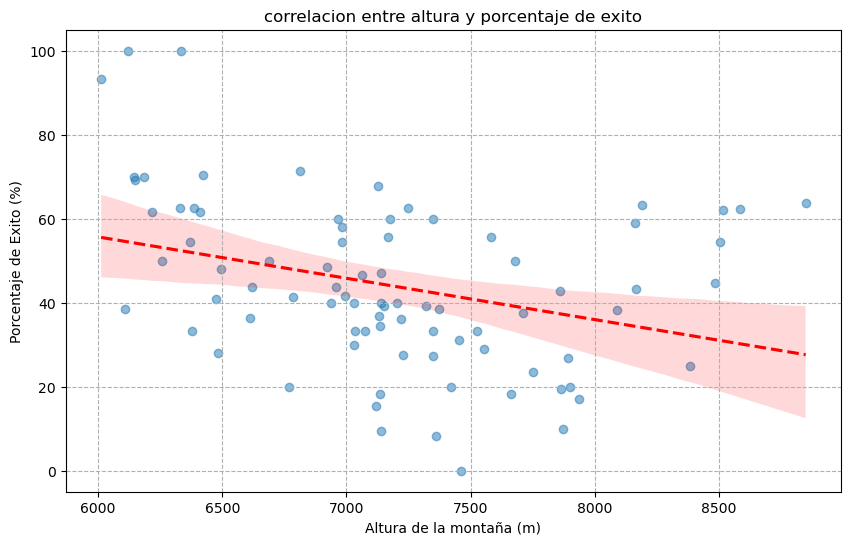

In [1135]:
df_actual = clean_df[["peakid", "pkname", "heightm", "success_exp", "failed_exp", "peak_success_p"]].drop_duplicates(subset = "peakid").reset_index(drop=True)
df_actual["total_exp"] = df_actual["success_exp"] + df_actual["failed_exp"]

df_actual = df_actual[df_actual["total_exp"] >= 10].copy()

correlacion = df_actual["heightm"].corr(df_actual["peak_success_p"])
print(f"La correlacion entre la altura y la montaña es de {round(correlacion , 4)}")

plt.figure(figsize=(10,6))
sns.regplot(data = df_actual , x = "heightm" , y = "peak_success_p" , scatter_kws = {"alpha" : 0.5} , line_kws = {"color" : "red" , "linestyle" : "--"})

plt.title("correlacion entre altura y porcentaje de exito")
plt.xlabel("Altura de la montaña (m)")
plt.ylabel("Porcentaje de Exito (%)")
plt.grid(True , linestyle='--' )
plt.show()

## 5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su **X** (matriz de atributos) e **y** (etiqueta a predecir) de la siguiente manera:

* **X**: `age`, `sex`, `citizen`, `season`, `heightm`, `year`, `success_exp`, `failed_exp`
* **y**: `msuccess`

Luego, realice los pasos a continuación:

**5.1 Codificación y normalización (1 pto)**
* Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos.
* Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
* Normalice sus matrices de atributos. Justifique su método de normalización.

**5.2 Creación y entrenamiento de modelos (1 pto)**
* Cree y entrene los siguientes modelos:
    * Un clasificador KNN
    * Un árbol de decisión
    * Un clasificador de regresión logística
    * Un clasificador random forest **(Opcional)**

    Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

* Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre
    * Accuracy
    * Precisión
    * Recall
    * Matriz de confusión

**5.3 Análisis de resultados (0.5 pts)**

Interprete, analice y comente sus resultados. 
* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 
* ¿Fue posible construir un predictor efectivo? Justique.



In [1136]:
# respuestas

Respuestas:

### Como se puso en la pregunta 4-b se quiso ver como se veria el grafico sin la limpieza que se hizo , esta es la respuesa de como se veria

In [1137]:
df_unificado["age"] = df_unificado["year"] - df_unificado["yob"]


df_unificado["peak_success_p"]  = round(((df_unificado["success_exp"] / (df_unificado["success_exp"] + df_unificado["failed_exp"])) * 100) , 3 )

df_unificado.head()

,peakid,pkname,heightm,expid,year,season,memid,sex,yob,citizen,msuccess,success_exp,failed_exp,age,peak_success_p
0,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,2,M,1972.0,Australia,False,1123,453,29.0,71.256
1,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,1,M,1968.0,Australia,False,1123,453,33.0,71.256
2,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,3,M,1960.0,Australia,False,1123,453,41.0,71.256
3,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,4,M,1966.0,Australia,False,1123,453,35.0,71.256
4,AMAD,Ama Dablam,6814,AMAD01101,2001,Spring,5,F,1970.0,Australia,False,1123,453,31.0,71.256


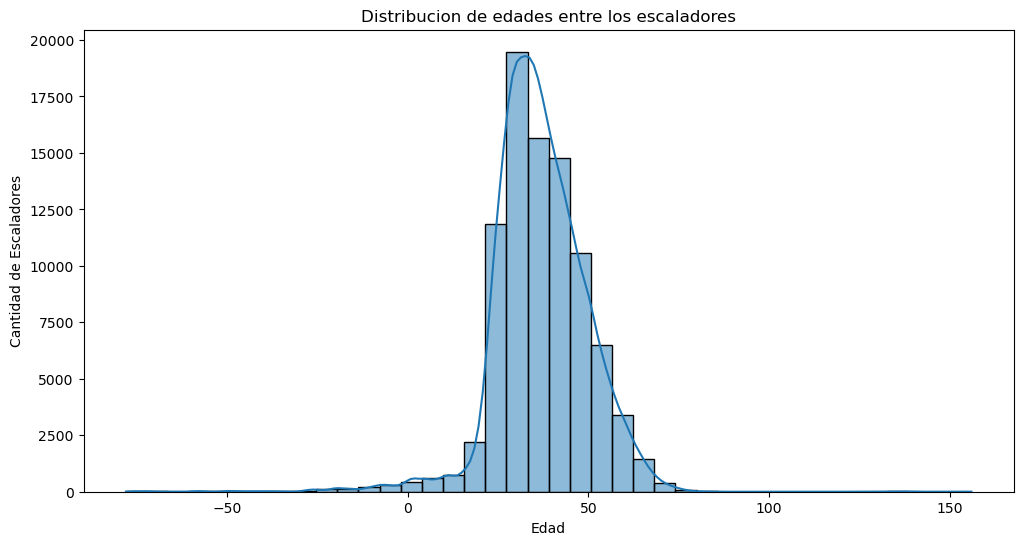

In [1138]:
plt.figure(figsize=(12,6))
sns.histplot(df_unificado, x = "age" , bins = 40 , kde=True)
plt.title("Distribucion de edades entre los escaladores")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Escaladores")
plt.show()


Si bien el hacer el grafico sin los datos "limpios" no estaba pedido, con esto podemos ver la importancia de la limpieza de datos, pricipalmente con datos incongruentes como que una persona tenga 150 años , esto tambien deja la pregunta de , como se veria todos nuestros analisis sin toda la limpieza asociada 